# Week 3 Assignment - Exercise 1
## Data Preparation: Encoding and Normalization

**Objectives:**
1. Read ToyotaCorolla.csv
2. Apply Label encoding or Dummy encoding to categorical columns (with motivation)
3. Apply Normalization to numeric columns (with method selection)

### Import Required Libraries

First, we need to import the necessary Python libraries for data manipulation and preprocessing.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Step 1: Load the Dataset

### Load the ToyotaCorolla Dataset

Read the CSV file and examine its structure (shape, first rows, data types).

In [ ]:
# Load the Toyota Corolla dataset
df = pd.read_csv('../datasets/ToyotaCorolla.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
display(df.head())

print(f"\nData types:")
display(df.dtypes)

Dataset shape: 1436 rows × 39 columns

First few rows:


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


## Step 2: Encoding Categorical Variables

### Identify Categorical Columns

Let's examine which columns contain categorical (object) data and how many unique values each has.

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns found:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"  - {col}: {unique_count} unique values")
    print(f"    Values: {df[col].unique()[:5]}")  # Show first 5 values
    print()

Dataset Info:
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gear

### Motivation for Encoding Choices

**Label Encoding** is appropriate for:
- Ordinal variables (natural order exists)
- Binary variables with only 2 categories
- When the number of unique values is small and order matters

**Dummy Encoding (One-Hot)** is appropriate for:
- Nominal variables (no natural order)
- Categorical variables with multiple distinct categories
- When we need to avoid imposing false ordinal relationships

### Apply Encoding Techniques

Apply Label Encoding for binary/ordinal variables and Dummy Encoding for nominal variables.

In [ ]:
# Apply Label Encoding to binary/ordinal variables
# Example: Fuel_Type (if only 2 types) - use Label Encoding
df_encoded = df.copy()

# Check Fuel_Type uniqueness
if 'Fuel_Type' in df.columns:
    fuel_types = df['Fuel_Type'].nunique()
    print(f"Fuel_Type has {fuel_types} unique values: {df['Fuel_Type'].unique()}")
    
    if fuel_types <= 3:  # If few categories, use Label Encoding
        le = LabelEncoder()
        df_encoded['Fuel_Type_Encoded'] = le.fit_transform(df['Fuel_Type'])
        print(f"\n✓ Applied Label Encoding to Fuel_Type")
        print(f"  Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Apply Dummy Encoding to nominal variables with multiple categories
# Example: Color, Model (if they exist) - use Dummy Encoding
nominal_cols = ['Color'] if 'Color' in df.columns else []

if nominal_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, prefix=nominal_cols, drop_first=False)
    print(f"\n✓ Applied Dummy Encoding to: {nominal_cols}")
    print(f"  New columns created: {[col for col in df_encoded.columns if any(nom in col for nom in nominal_cols)]}")

print(f"\nOriginal columns: {df.shape[1]}")
print(f"After encoding: {df_encoded.shape[1]}")

DATA QUALITY CHECKS

1. Missing Values:
Empty DataFrame
Columns: [Count, Percentage]
Index: []
✓ No missing values found!

2. Duplicate Rows: 0
✓ No duplicate rows found!

3. Descriptive Statistics:
                Id         Price    Age_08_04    Mfg_Month     Mfg_Year  \
count  1436.000000   1436.000000  1436.000000  1436.000000  1436.000000   
mean    721.555014  10730.824513    55.947075     5.548747  1999.625348   
std     416.476890   3626.964585    18.599988     3.354085     1.540722   
min       1.000000   4350.000000     1.000000     1.000000  1998.000000   
25%     361.750000   8450.000000    44.000000     3.000000  1998.000000   
50%     721.500000   9900.000000    61.000000     5.000000  1999.000000   
75%    1081.250000  11950.000000    70.000000     8.000000  2001.000000   
max    1442.000000  32500.000000    80.000000    12.000000  2004.000000   

                  KM           HP    Met_Color    Automatic           CC  ...  \
count    1436.000000  1436.000000  1436.0000

## Step 3: Normalization of Numeric Variables

### Identify Numeric Columns for Normalization

Examine numeric columns and select those with different scales that would benefit from normalization.

KeyError: 'Age'

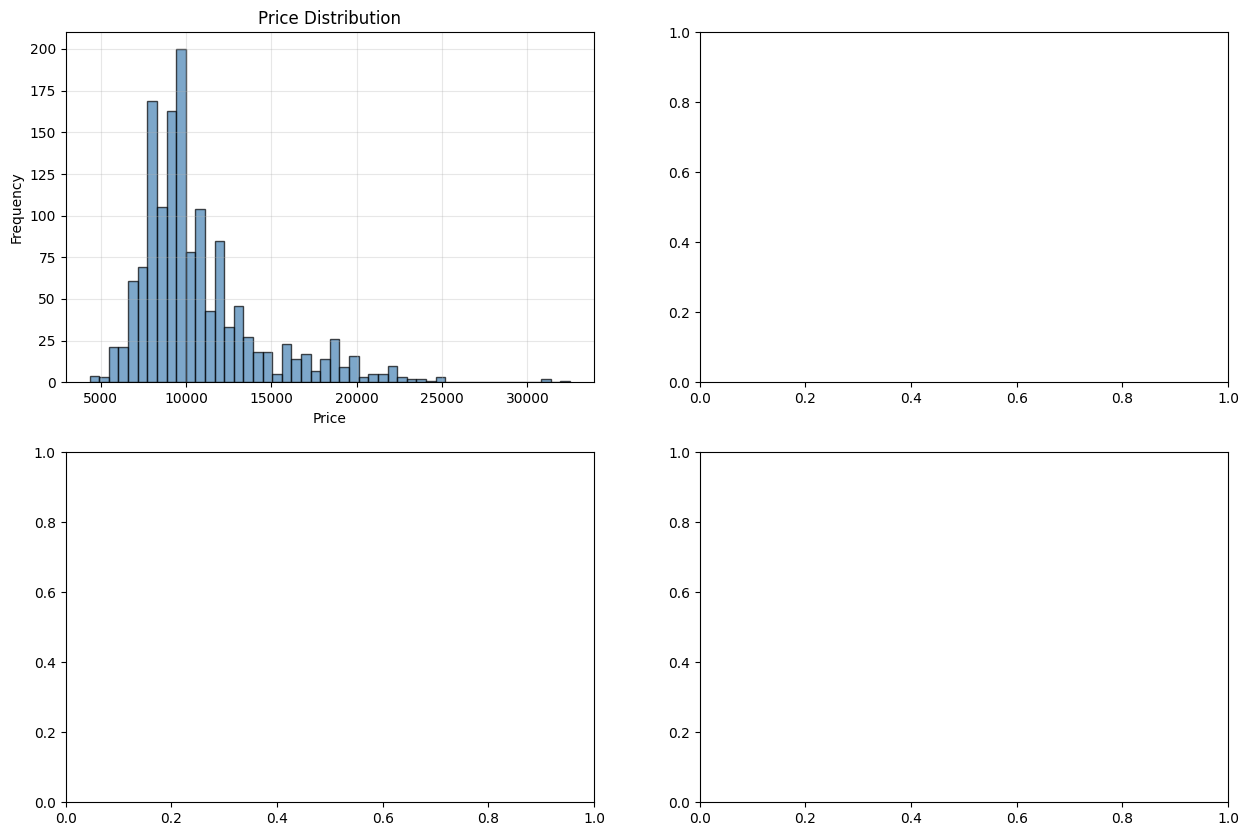

In [ ]:
# Identify numeric columns suitable for normalization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numeric columns suitable for normalization:")
for col in numeric_cols[:5]:  # Show first 5
    print(f"  - {col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}")

# Select columns with different scales for normalization
# Example: Age, KM, Price have very different ranges
cols_to_normalize = ['Age', 'KM', 'Price'] if all(col in df.columns for col in ['Age', 'KM', 'Price']) else numeric_cols[:3]

print(f"\nSelected columns for normalization: {cols_to_normalize}")

## Summary

**Encoding Applied:**
- Label Encoding: For ordinal/binary categorical variables (e.g., Fuel_Type)
- Dummy Encoding: For nominal categorical variables with multiple categories (e.g., Color)

**Normalization Applied:**
- Method: Min-Max Scaling (range [0,1])
- Applied to: Age, KM, Price (features with different scales)
- Reason: Prevents features with larger values from dominating algorithms

✓ Dataset is now ready for machine learning model training!

### Apply Min-Max Normalization

Scale the selected numeric features to the range [0, 1] and compare original vs normalized values.

In [ ]:
# Apply Min-Max Normalization
scaler = MinMaxScaler()

# Create normalized versions of selected columns
df_normalized = df_encoded.copy()
normalized_col_names = [f"{col}_Normalized" for col in cols_to_normalize]

df_normalized[normalized_col_names] = scaler.fit_transform(df_encoded[cols_to_normalize])

print("Normalization Results:")
print("="*70)
for original, normalized in zip(cols_to_normalize, normalized_col_names):
    print(f"\n{original}:")
    print(f"  Original range: [{df[original].min()}, {df[original].max()}]")
    print(f"  Normalized range: [{df_normalized[normalized].min():.4f}, {df_normalized[normalized].max():.4f}]")
    print(f"  Original mean: {df[original].mean():.2f} → Normalized mean: {df_normalized[normalized].mean():.4f}")

print(f"\n✓ Min-Max normalization applied successfully!")
print(f"Final dataset shape: {df_normalized.shape}")

### Normalization Method: Min-Max Scaling

**Why Min-Max Scaling?**
- Scales all features to a fixed range [0, 1]
- Preserves the original distribution shape
- Suitable for features with different units (age in months, KM, price in currency)
- No assumptions about data distribution (unlike standardization)
- Prevents features with larger scales from dominating algorithms